<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Alpha_Decay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

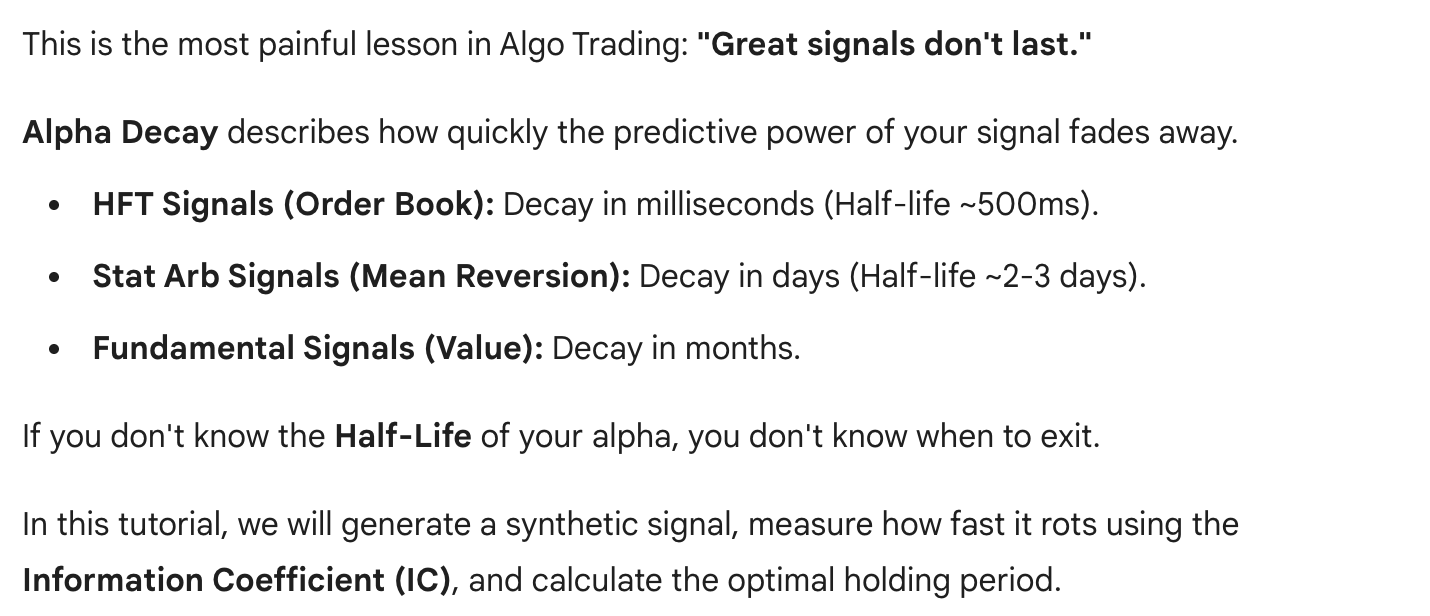

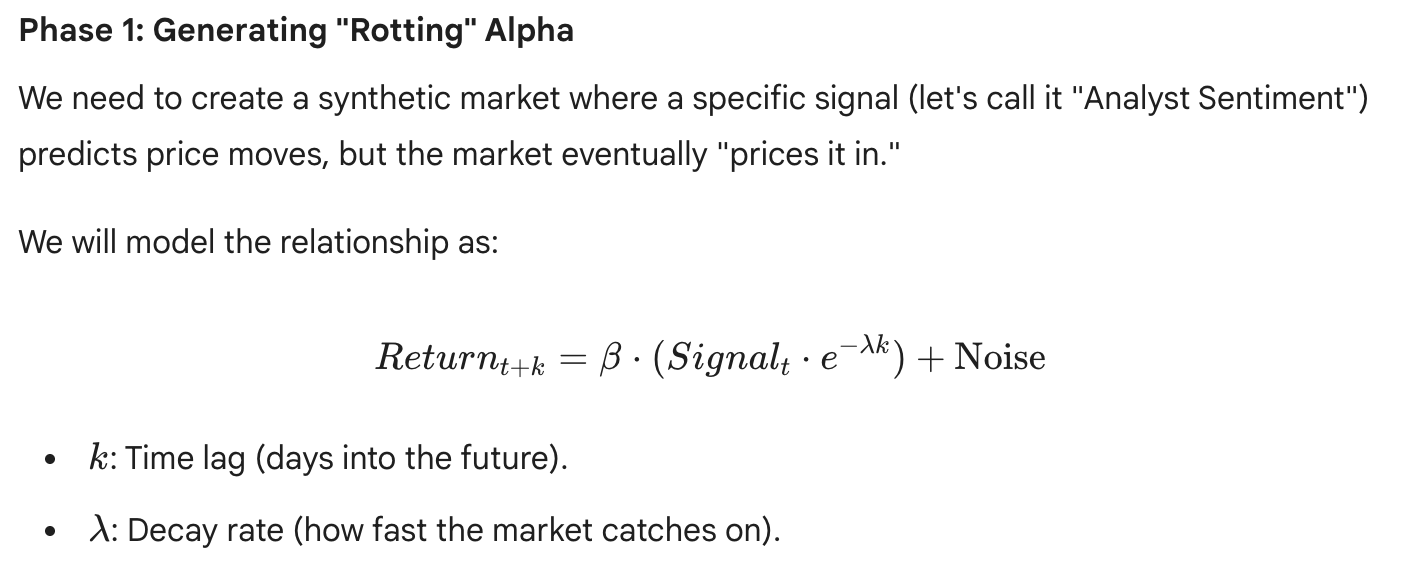

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

In [2]:
# --- CONFIGURATION ---
N_DAYS = 5000
DECAY_RATE = 0.1 # The signal loses ~10% of its power every day
NOISE_LEVEL = 0.02

In [3]:
def generate_decaying_alpha():
    np.random.seed(42)

    # 1. Generate the Signal (e.g., a daily proprietary score)
    # The signal itself has some memory (autocorrelation)
    raw_signal = np.random.normal(0, 1, N_DAYS)

    # 2. Generate Future Returns based on this Signal
    # The signal at time 't' impacts returns at t+1, t+2, t+3... but with less strength

    future_returns = np.zeros(N_DAYS)

    # We iterate to build the return stream composed of many past signals fading out
    # This is a convolution of Signal and Decay Kernel

    # Create the decay kernel (Influence of a signal over 20 days)
    horizon = 20
    kernel = np.exp(-DECAY_RATE * np.arange(horizon))

    # Convolve: The return today is the sum of (Yesterday's Signal * 0.9) + (Day Before * 0.8)...
    # This simulates the market slowly reacting to the information
    future_returns = np.convolve(raw_signal, kernel, mode='full')[:N_DAYS]

    # Add Market Noise (The Alpha is hard to see)
    noise = np.random.normal(0, NOISE_LEVEL, N_DAYS) * 50
    realized_returns = future_returns + noise

    df = pd.DataFrame({
        'Signal': raw_signal,
        'Return': realized_returns
    })

    return df

In [4]:
df = generate_decaying_alpha()

# Quick check: Does the signal predict T+1 return?
corr = df['Signal'].corr(df['Return'].shift(-1))
print(f"✅ Baseline Correlation (Lag 1): {corr:.4f}")

✅ Baseline Correlation (Lag 1): 0.3481


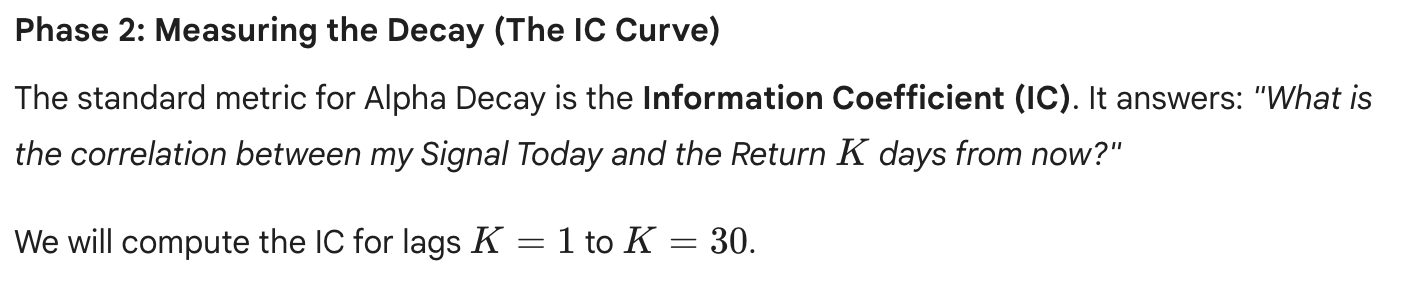

In [5]:
def calculate_ic_decay(df, max_lag=20):
    ic_values = []
    lags = range(1, max_lag + 1)

    for lag in lags:
        # Spearman Rank Correlation is more robust to outliers than Pearson
        # We compare Signal(t) vs Return(t + lag)
        corr, _ = spearmanr(df['Signal'], df['Return'].shift(-lag), nan_policy='omit')
        ic_values.append(corr)

    return pd.DataFrame({'Lag': lags, 'IC': ic_values})

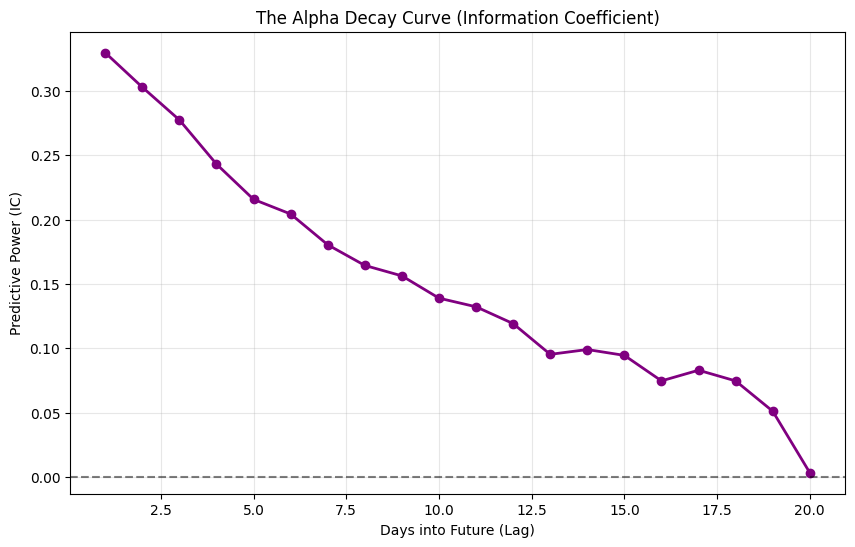

In [6]:
ic_df = calculate_ic_decay(df)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(ic_df['Lag'], ic_df['IC'], marker='o', linestyle='-', color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("The Alpha Decay Curve (Information Coefficient)")
plt.xlabel("Days into Future (Lag)")
plt.ylabel("Predictive Power (IC)")
plt.grid(True, alpha=0.3)
plt.show()

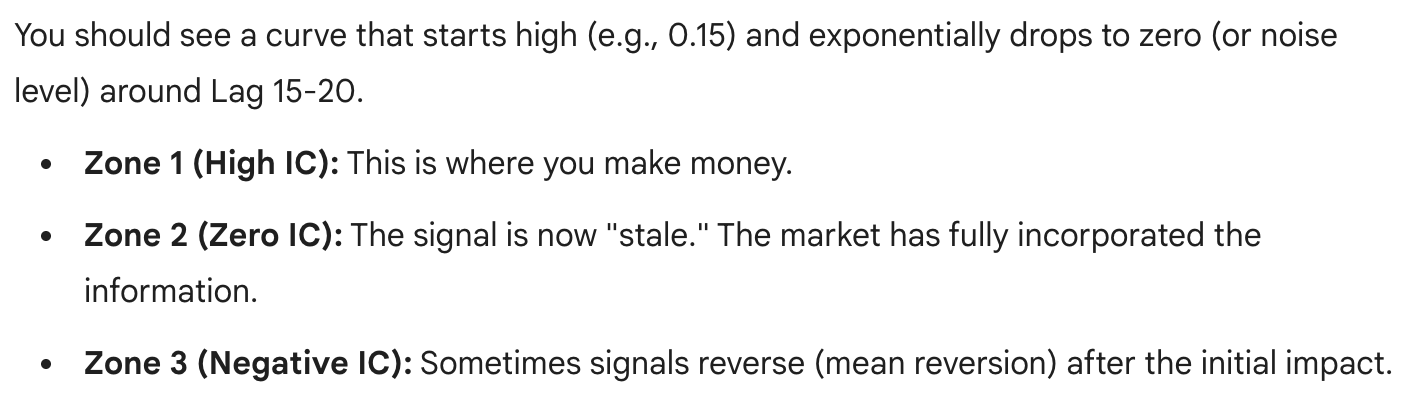

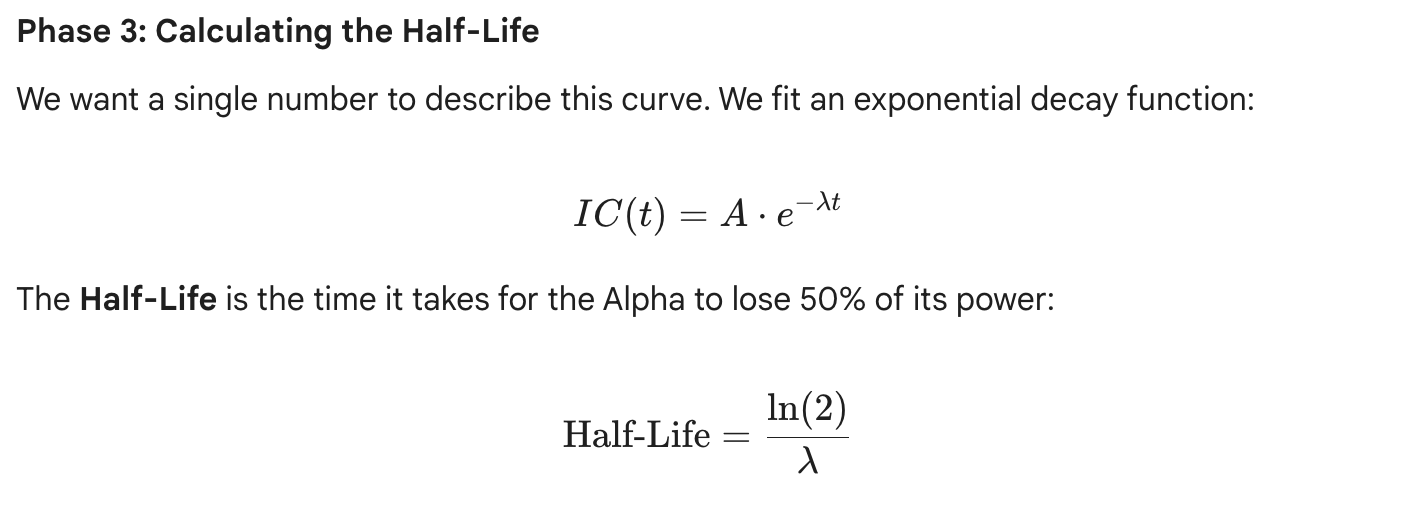

📊 Model Fit Results:
   -> Initial Strength (A): 0.3660
   -> Decay Rate (lambda):  0.0983
   -> Alpha Half-Life:      7.05 Days


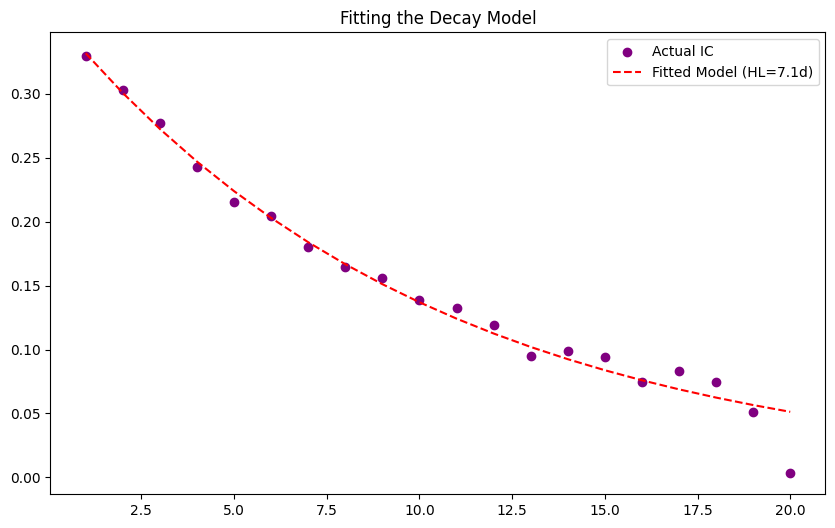

In [7]:
from scipy.optimize import curve_fit

def decay_func(t, A, decay_rate):
    return A * np.exp(-decay_rate * t)

# 1. Get X and Y data
x_data = ic_df['Lag'].values
y_data = ic_df['IC'].values

# 2. Fit the model
# Initial guess: Amplitude=0.2, Decay=0.1
popt, pcov = curve_fit(decay_func, x_data, y_data, p0=[0.2, 0.1])
A_est, lambda_est = popt

# 3. Calculate Half-Life
half_life = np.log(2) / lambda_est

print(f"📊 Model Fit Results:")
print(f"   -> Initial Strength (A): {A_est:.4f}")
print(f"   -> Decay Rate (lambda):  {lambda_est:.4f}")
print(f"   -> Alpha Half-Life:      {half_life:.2f} Days")

# Plot Fit vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label='Actual IC', color='purple')
plt.plot(x_data, decay_func(x_data, *popt), label=f'Fitted Model (HL={half_life:.1f}d)', color='red', linestyle='--')
plt.legend()
plt.title("Fitting the Decay Model")
plt.show()

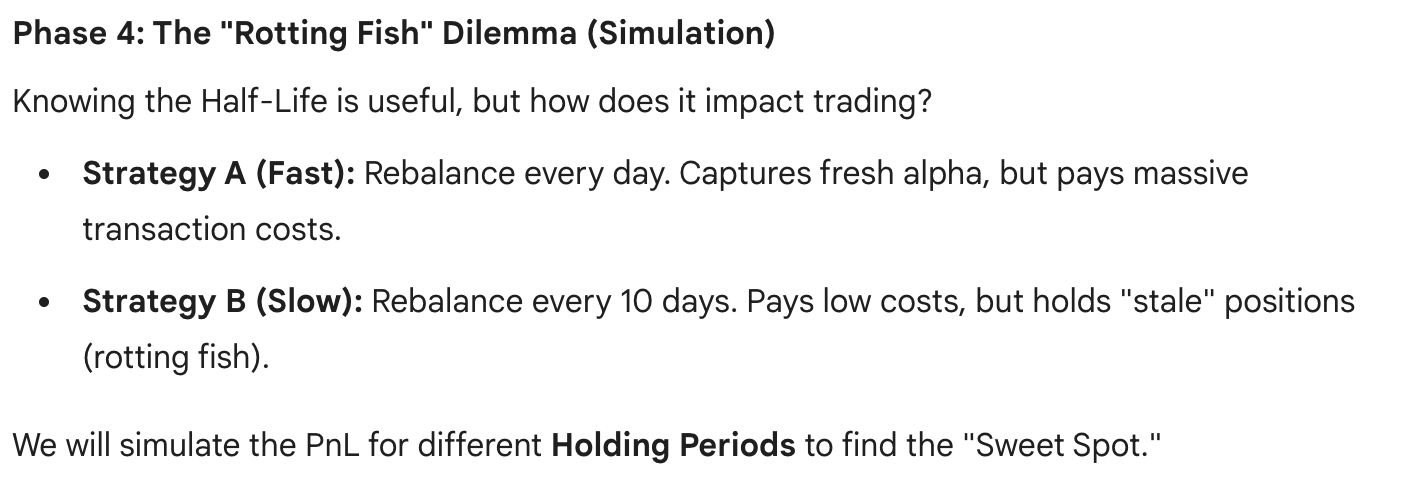

In [9]:
# --- SIMULATION PARAMETERS ---
TRANSACTION_COST_BPS = 5 # 5 basis points per trade (0.05%)
HOLDING_PERIODS = [1, 3, 5, 10, 20]

results = []

for hp in HOLDING_PERIODS:
    # 1. Generate Positions based on Signal
    # We rebalance only every 'hp' days.
    # Between rebalances, we hold the position constant.

    positions = np.zeros(len(df))

    # Vectorized "Rebalance on schedule" logic
    # We take the signal at day t, and hold it for hp days
    for t in range(0, len(df) - hp, hp):
        sig = df['Signal'].iloc[t]
        # Simple Logic: Long if Signal > 0, Short if Signal < 0
        pos = 1.0 if sig > 0 else -1.0
        positions[t : t+hp] = pos

    positions = pd.Series(positions, index=df.index)

    # 2. Calculate Gross Returns
    # Return = Position * Tomorrow's Return
    gross_pnl = positions * df['Return'].shift(-1)

    # 3. Calculate Transaction Costs
    # Cost is paid whenever position changes
    trades = positions.diff().abs().fillna(0) # 0 to 1 = 1 unit traded. 1 to -1 = 2 units.
    # Cost = Units Traded * Price (assumed 100 for bps calculation context) * Bps
    # Simplified: Just penalize the PnL directly
    # Assume 1 unit of position ~ $100 capital. 5bps = $0.05 cost per unit traded.
    # Adjust this scaler to match the volatility of our synthetic returns
    cost_penalty = trades * (TRANSACTION_COST_BPS * 0.01) * 10

    net_pnl = gross_pnl - cost_penalty

    # 4. Metrics
    total_ret = net_pnl.sum()
    sharpe = net_pnl.mean() / net_pnl.std() * np.sqrt(252)
    turnover = trades.sum() / len(df) # Average trades per day

    results.append({
        'Holding_Period': hp,
        'Total_Return': total_ret,
        'Sharpe': sharpe,
        'Turnover': turnover
    })

res_df = pd.DataFrame(results)
print(res_df)

   Holding_Period  Total_Return    Sharpe  Turnover
0               1    973.113706  1.192472    1.0090
1               3   2368.453756  3.020307    0.3254
2               5   2256.925520  2.889226    0.2030
3              10   1772.422462  2.265521    0.1014
4              20   1417.390498  1.807346    0.0510


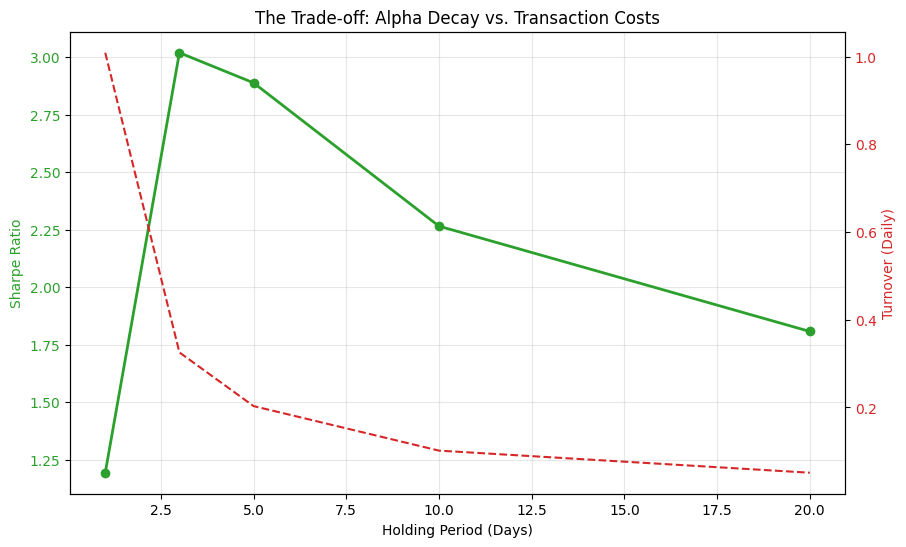

In [10]:
# --- PLOT THE SWEET SPOT ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:green'
ax1.set_xlabel('Holding Period (Days)')
ax1.set_ylabel('Sharpe Ratio', color=color)
ax1.plot(res_df['Holding_Period'], res_df['Sharpe'], color=color, marker='o', linewidth=2, label='Sharpe Ratio')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Turnover (Daily)', color=color)
ax2.plot(res_df['Holding_Period'], res_df['Turnover'], color=color, linestyle='--', label='Turnover')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("The Trade-off: Alpha Decay vs. Transaction Costs")
plt.show()

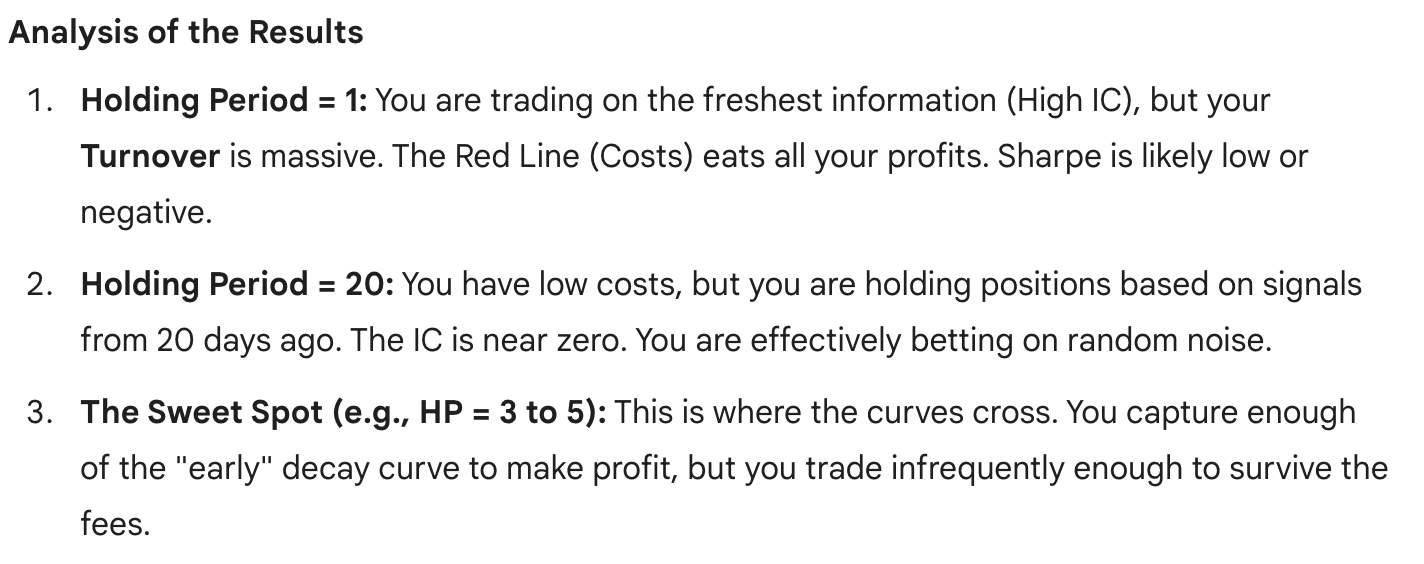